# Proyecto UD4
#### UD4. Redes Neuronais
#### MP. Sistemas de Aprendizaxe Automáticos
#### IES de Teis (Vigo),Vanesa Resúa Eiras, Cristina Gómez Alonso


### Datasets de Clasificación: Cristales vs Crédito

Para este proyecto os doy opción a que escojáis entre dos datasets diferentes.
El primero no os exigirá ningún preprocesado previo, mientras que el segundo sí.
Por otro lado, el primero es clasificación multiclase, mientras que el segundo es de clasificación binaria.
La calificación máxima en caso de que escojáis el primero será de 8 puntos mientras que si escojéis el segundo será de 10 puntos.

#### Dataset Crédito

Disponemos de un dataset con 1000 instancias clasificadas en 2 tipos diferentes de clientes: a los que se les otorga un crédito y a los que no.

Lista de atributos para cada entrada será:

* checking_status: estado de la cuenta corriente existente, en marcos alemanes.
* duration: duración en meses
* credit_history: historial crediticio (créditos tomados, reembolsados debidamente, atrasos, cuentas críticas)
* purpose: finalidad del crédito (coche, televisión,…)
* credit_amount: cantidad solicitada de crédito
* saving_status: estado de su cuenta de ahorro/bonos, en marcos alemanes.
* employment: empleo actual en número de años.
* installament_commitment: tasa de cuota en porcentaje de ingresos disponibles
* personal_status: estado personal (casado, soltero,…) y sexo
* other_parties: otros deudores / garantes
* residence_since: residencia actual desde hace X años
* property_magnitude: propiedades (por ejemplo, casas, pisos...)
* age: Edad en años
* other_payment_plans: otros planes de cuotas (bancos, tiendas)
* housing: vivienda (alquiler, propia,…)
* existing_credits: número de créditos existentes con esta entidad
* job: trabajo
* num_dependents: número de personas dependientes o a las que proporcionan manuntención
* own_phone: teléfono (yes, no)
* foreign_worker: trabajador extranjero (yes, no)
* class: clase: good (crédito otorgado), bad (crédito denegado)

Escoge uno de los dos datasets anteriores y resuelve los siguientes apartados.

## 1. Importación del dataset

In [ ]:
import os
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
warnings.filterwarnings("ignore")

import math

import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.gridspec as gridspec
from scipy import stats


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, balanced_accuracy_score, f1_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization # type: ignore
from tensorflow.keras.callbacks import EarlyStopping # type: ignore

seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

I0000 00:00:1778572835.446562   22821 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778572840.078266   22821 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
creditos = pd.read_csv('credits.csv')
creditos

,ID,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,vty,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,dkl,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,bwf,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,qln,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,uzh,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,...,no known property,53,none,for free,2,skilled,2,none,yes,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,jlf,no checking,12,existing paid,furniture/equipment,1736,<100,4<=X<7,3,female div/dep/mar,...,real estate,31,none,own,1,unskilled resident,1,none,yes,good
996,imr,<0,30,existing paid,used car,3857,<100,1<=X<4,4,male div/sep,...,life insurance,140,none,own,1,high qualif/self emp/mgmt,1,yes,yes,good
997,xnt,no checking,12,existing paid,radio/tv,804,<100,>=7,4,male single,...,car,38,none,own,1,skilled,1,none,yes,good
998,egn,<0,45,existing paid,radio/tv,1845,<100,1<=X<4,4,male single,...,no known property,23,none,for free,1,skilled,1,yes,yes,bad


## 2. EDA&Preprocessing (2 puntos crédito, 1 punto cristales)

In [3]:
print(f"Nuestro dataframe tiene {creditos.shape[0]} filas y {creditos.shape[1]} columnas")


Nuestro dataframe tiene 1000 filas y 22 columnas


In [4]:
creditos.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.746000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,12.367961,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,149.000000,4.000000,2.000000


In [5]:
creditos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   ID                      999 non-null    object
 1   checking_status         1000 non-null   object
 2   duration                1000 non-null   int64 
 3   credit_history          1000 non-null   object
 4   purpose                 1000 non-null   object
 5   credit_amount           1000 non-null   int64 
 6   savings_status          1000 non-null   object
 7   employment              1000 non-null   object
 8   installment_commitment  1000 non-null   int64 
 9   personal_status         1000 non-null   object
 10  other_parties           1000 non-null   object
 11  residence_since         1000 non-null   int64 
 12  property_magnitude      1000 non-null   object
 13  age                     1000 non-null   int64 
 14  other_payment_plans     1000 non-null   object
 15  housi

<div style="font-family: Arial, sans-serif; line-height: 1.6; color: #333;">

El dataset original cuenta con 1000 registros y 22 columnas. Contiene 15 variables categóricas (tipo object) que requerirán transformación, y se aprecian datos faltantes en las columnas ID y own_telephone


</div>

In [6]:
print(f"Valores duplicados: {creditos.duplicated().sum()}")

Valores duplicados: 0


In [7]:
creditos.isnull().sum()

ID                         1
checking_status            0
duration                   0
credit_history             0
purpose                    0
credit_amount              0
savings_status             0
employment                 0
installment_commitment     0
personal_status            0
other_parties              0
residence_since            0
property_magnitude         0
age                        0
other_payment_plans        0
housing                    0
existing_credits           0
job                        0
num_dependents             0
own_telephone             10
foreign_worker             0
class                      0
dtype: int64

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
Se observa la presencia de valores nulos en dos columnas:
</p>

<ul>
    <li>La columna <code style="color:#0b5394;">id</code> presenta <strong>1 valor nulo</strong>.</li>
    <li>La columna <code style="color:#0b5394;">own_telephone</code> contiene <strong>10 valores nulos</strong>.</li>
</ul>

<p>
Aunque la cantidad de valores faltantes es reducida, será importante considerarlos en el análisis posterior.
</p>

</div>

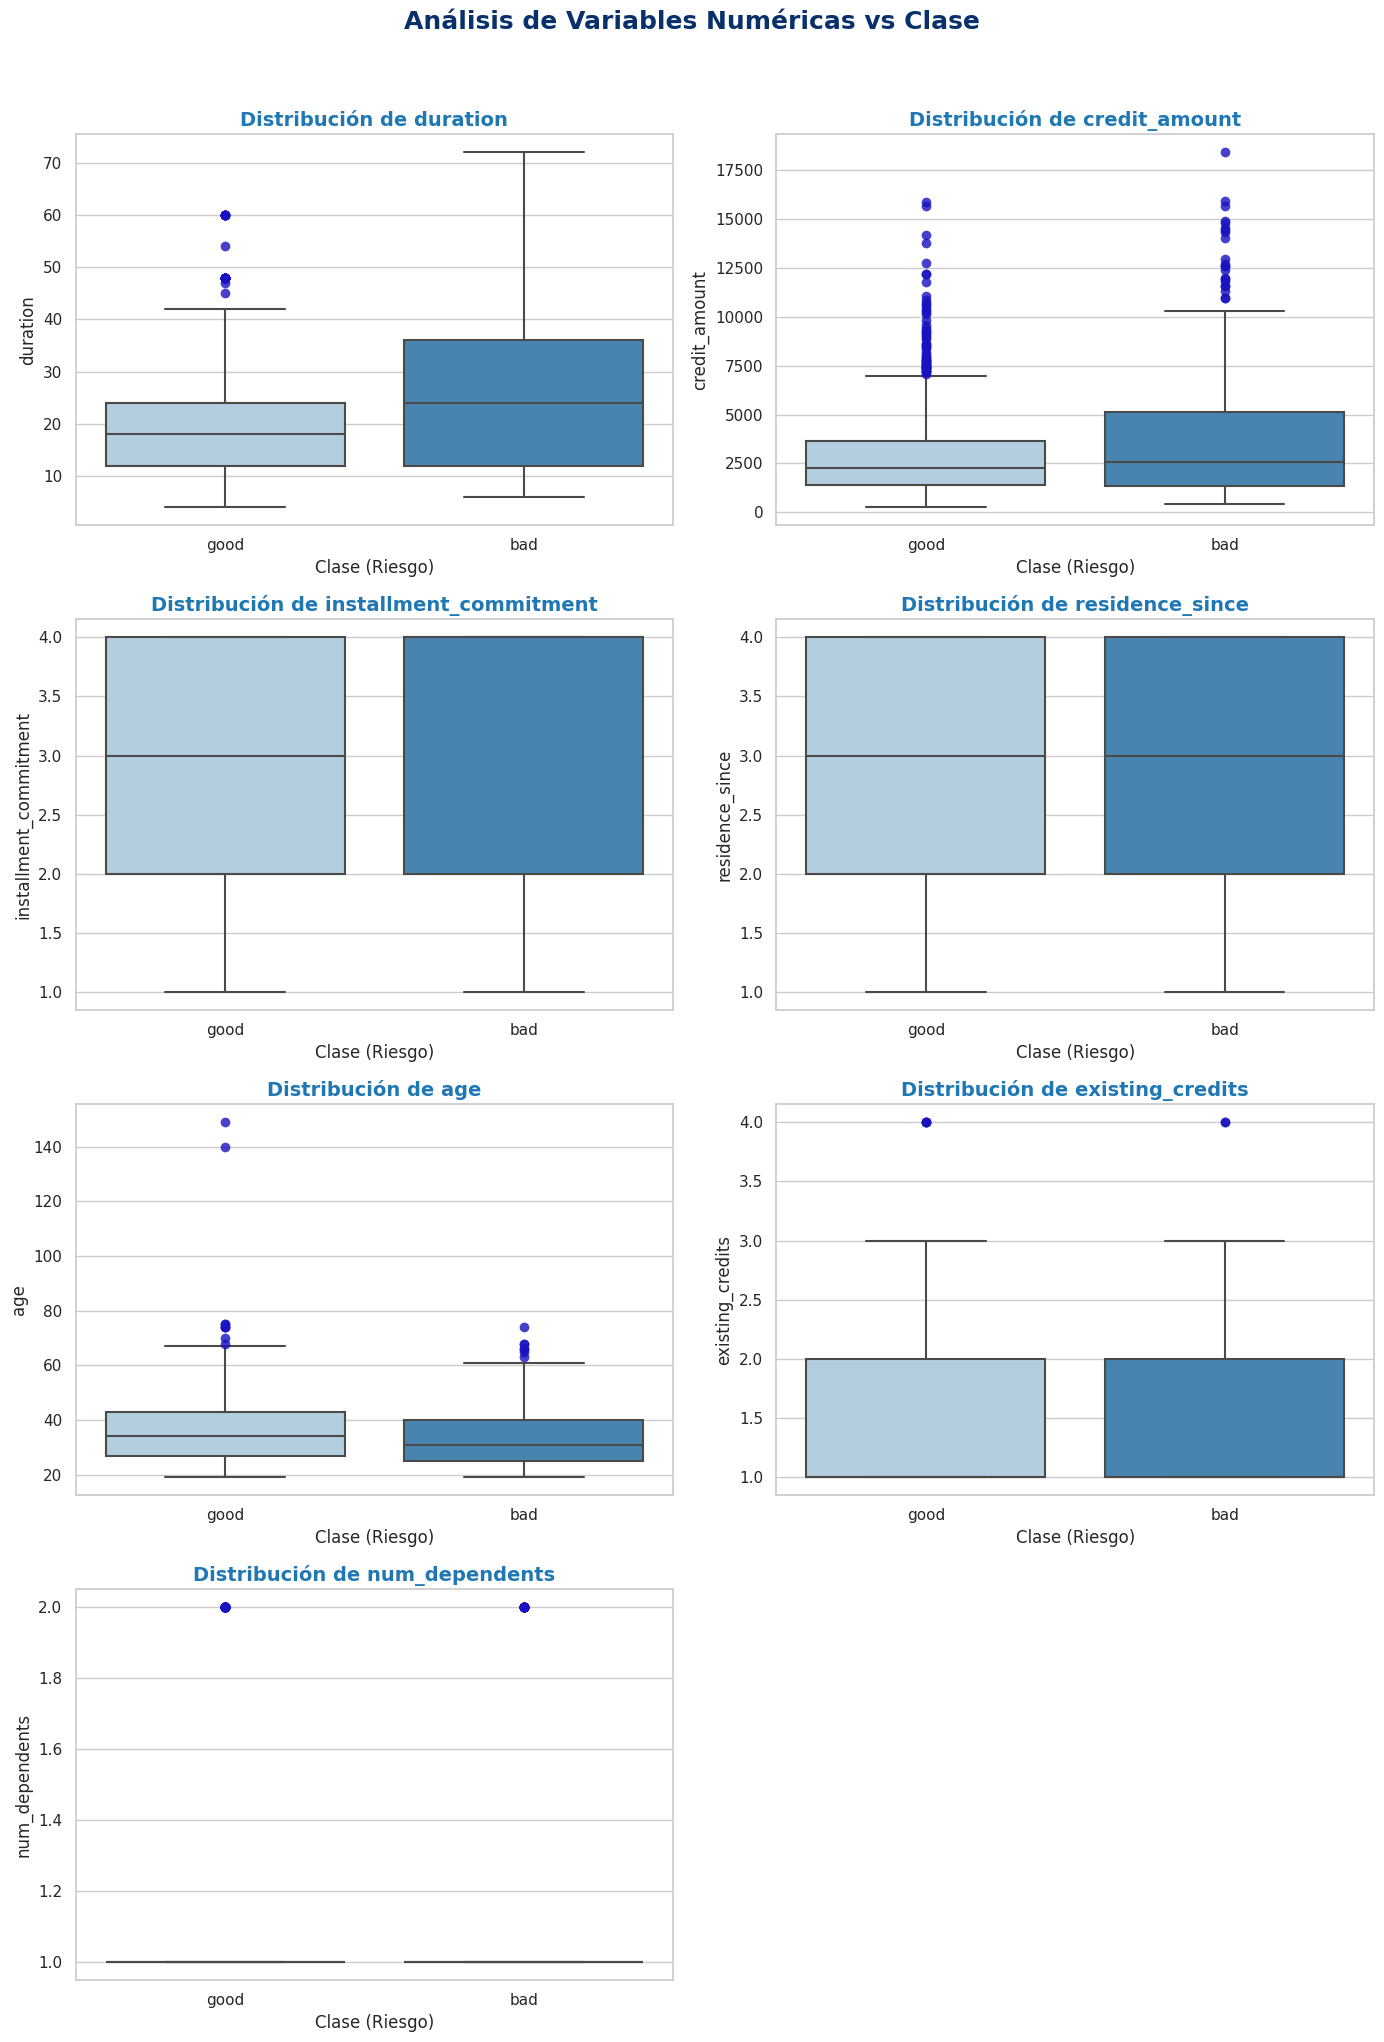

In [9]:
num_cols = creditos.select_dtypes(include=['int64', 'float64']).columns
n_cols = len(num_cols)

cols = 2
rows = math.ceil(n_cols / cols)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten()

outlier_props = dict(markerfacecolor="#1812c0", marker='o', markersize=7, alpha=0.8, markeredgecolor='none')

for i, var in enumerate(num_cols):
    sns.boxplot(
        x='class', 
        y=var, 
        data=creditos, 
        ax=axes[i], 
        palette="Blues",       
        flierprops=outlier_props,
        linewidth=1.5
    )
    axes[i].set_title(f'Distribución de {var}', fontsize=14, fontweight='bold', color='#1f77b4')
    axes[i].set_xlabel('Clase (Riesgo)', fontsize=12)
    axes[i].set_ylabel(var, fontsize=12)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Análisis de Variables Numéricas vs Clase', 
            fontsize=18, fontweight='bold', color='#08306b', y=1.02)
plt.tight_layout()
plt.show()

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
El análisis visual de las variables numéricas frente a la clase revela lo siguiente:
</p>

<ul style="margin-top: 8px;">
    <li>
        <strong>Importe y duración:</strong> Los créditos denegados (<code style="color:#0b5394;">bad</code>) suelen asociarse a plazos de devolución más largos y montos de dinero mayores.
    </li>
    <li>
        <strong>Edad:</strong> Existe una ligera tendencia a mayor morosidad en clientes más jóvenes.
    </li>
    <li>
        <strong>Valores atípicos (Outliers):</strong> Se observan registros poco realistas, como clientes con edades cercanas a los 150 años, lo que confirma la necesidad de un preprocesamiento adecuado.
    </li>
</ul>

</div>

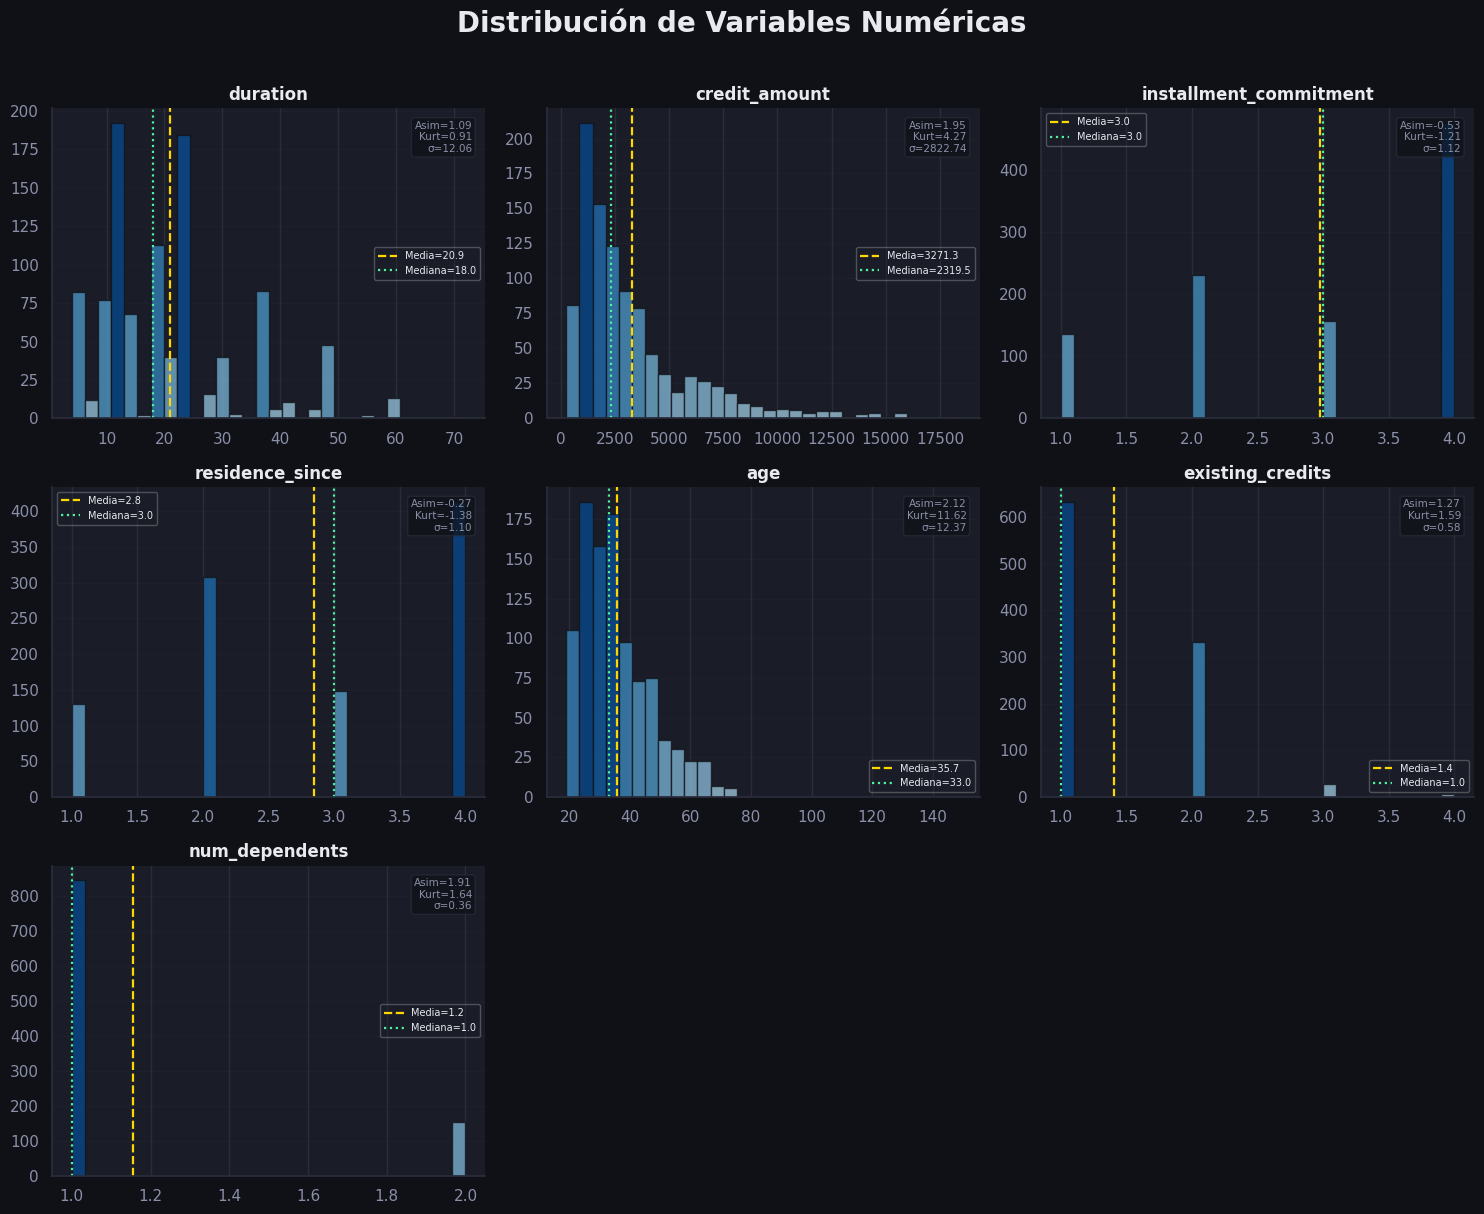

In [24]:

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2a2d3a', 'axes.labelcolor': '#8b8fa8',
    'axes.titlecolor': '#e8eaf0', 'xtick.color': '#8b8fa8',
    'ytick.color': '#8b8fa8', 'grid.color': '#2a2d3a',
    'text.color': '#e8eaf0', 'axes.spines.top': False, 'axes.spines.right': False,
})

numericas = creditos.select_dtypes(include=[np.number]).columns.tolist()
cols = 3
rows = int(np.ceil(len(numericas) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

fig.suptitle('Distribución de Variables Numéricas', fontsize=20,
            fontweight='bold', color='#e8eaf0', y=1.01)

for i, col in enumerate(numericas):
    ax = axes[i]
    data = creditos[col].dropna()

    n_counts, bin_edges, patches = ax.hist(data, bins=30, color='#4e9af1',
                                            edgecolor='#0f1117', alpha=0.75)
    for patch, count in zip(patches, n_counts):
        patch.set_facecolor(plt.cm.Blues(0.35 + 0.55 * count / n_counts.max()))

    ax.axvline(data.mean(),   color='#FFD700', lw=1.6, ls='--', label=f'Media={data.mean():.1f}')
    ax.axvline(data.median(), color='#4ef1a0', lw=1.6, ls=':',  label=f'Mediana={data.median():.1f}')
    

    # Stats en esquina
    skw, krt = stats.skew(data), stats.kurtosis(data)
    ax.text(0.97, 0.96, f"Asim={skw:.2f}\nKurt={krt:.2f}\nσ={data.std():.2f}",
            transform=ax.transAxes, fontsize=7.5, va='top', ha='right',
            color='#8b8fa8', bbox=dict(boxstyle='round,pad=0.3',
            facecolor='#0f1117', alpha=0.7, edgecolor='#2a2d3a'))

    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, framealpha=0.3, labelcolor='#e8eaf0', facecolor='#1a1d27')
    ax.grid(axis='y', alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #1f3a5f; max-width: 700px;">
<ul>
<p>
<li><strong>La distribución no es simétrica</strong>. La gran mayoría de los préstamos se concentran en importes bajos entre 1,000 y 5,000</li>
<li><strong>Duración del préstamo:</strong> plazos estándar 12, 24 y 36 meses. Los plazos largos >48 meses aparecen como <em>outliers</em>. A mayor duración, mayor es la incertidumbre y, por tanto, el riesgo de impago.</li>
</ul>
<p>
Dado que modelos como la Regresión Logística y las Redes Neuronales son sensibles a la escala y a la varianza, estos valores tan extremos hacen que el <strong>escalado de datos</strong> sea un paso obligatorio
</p>

</div>

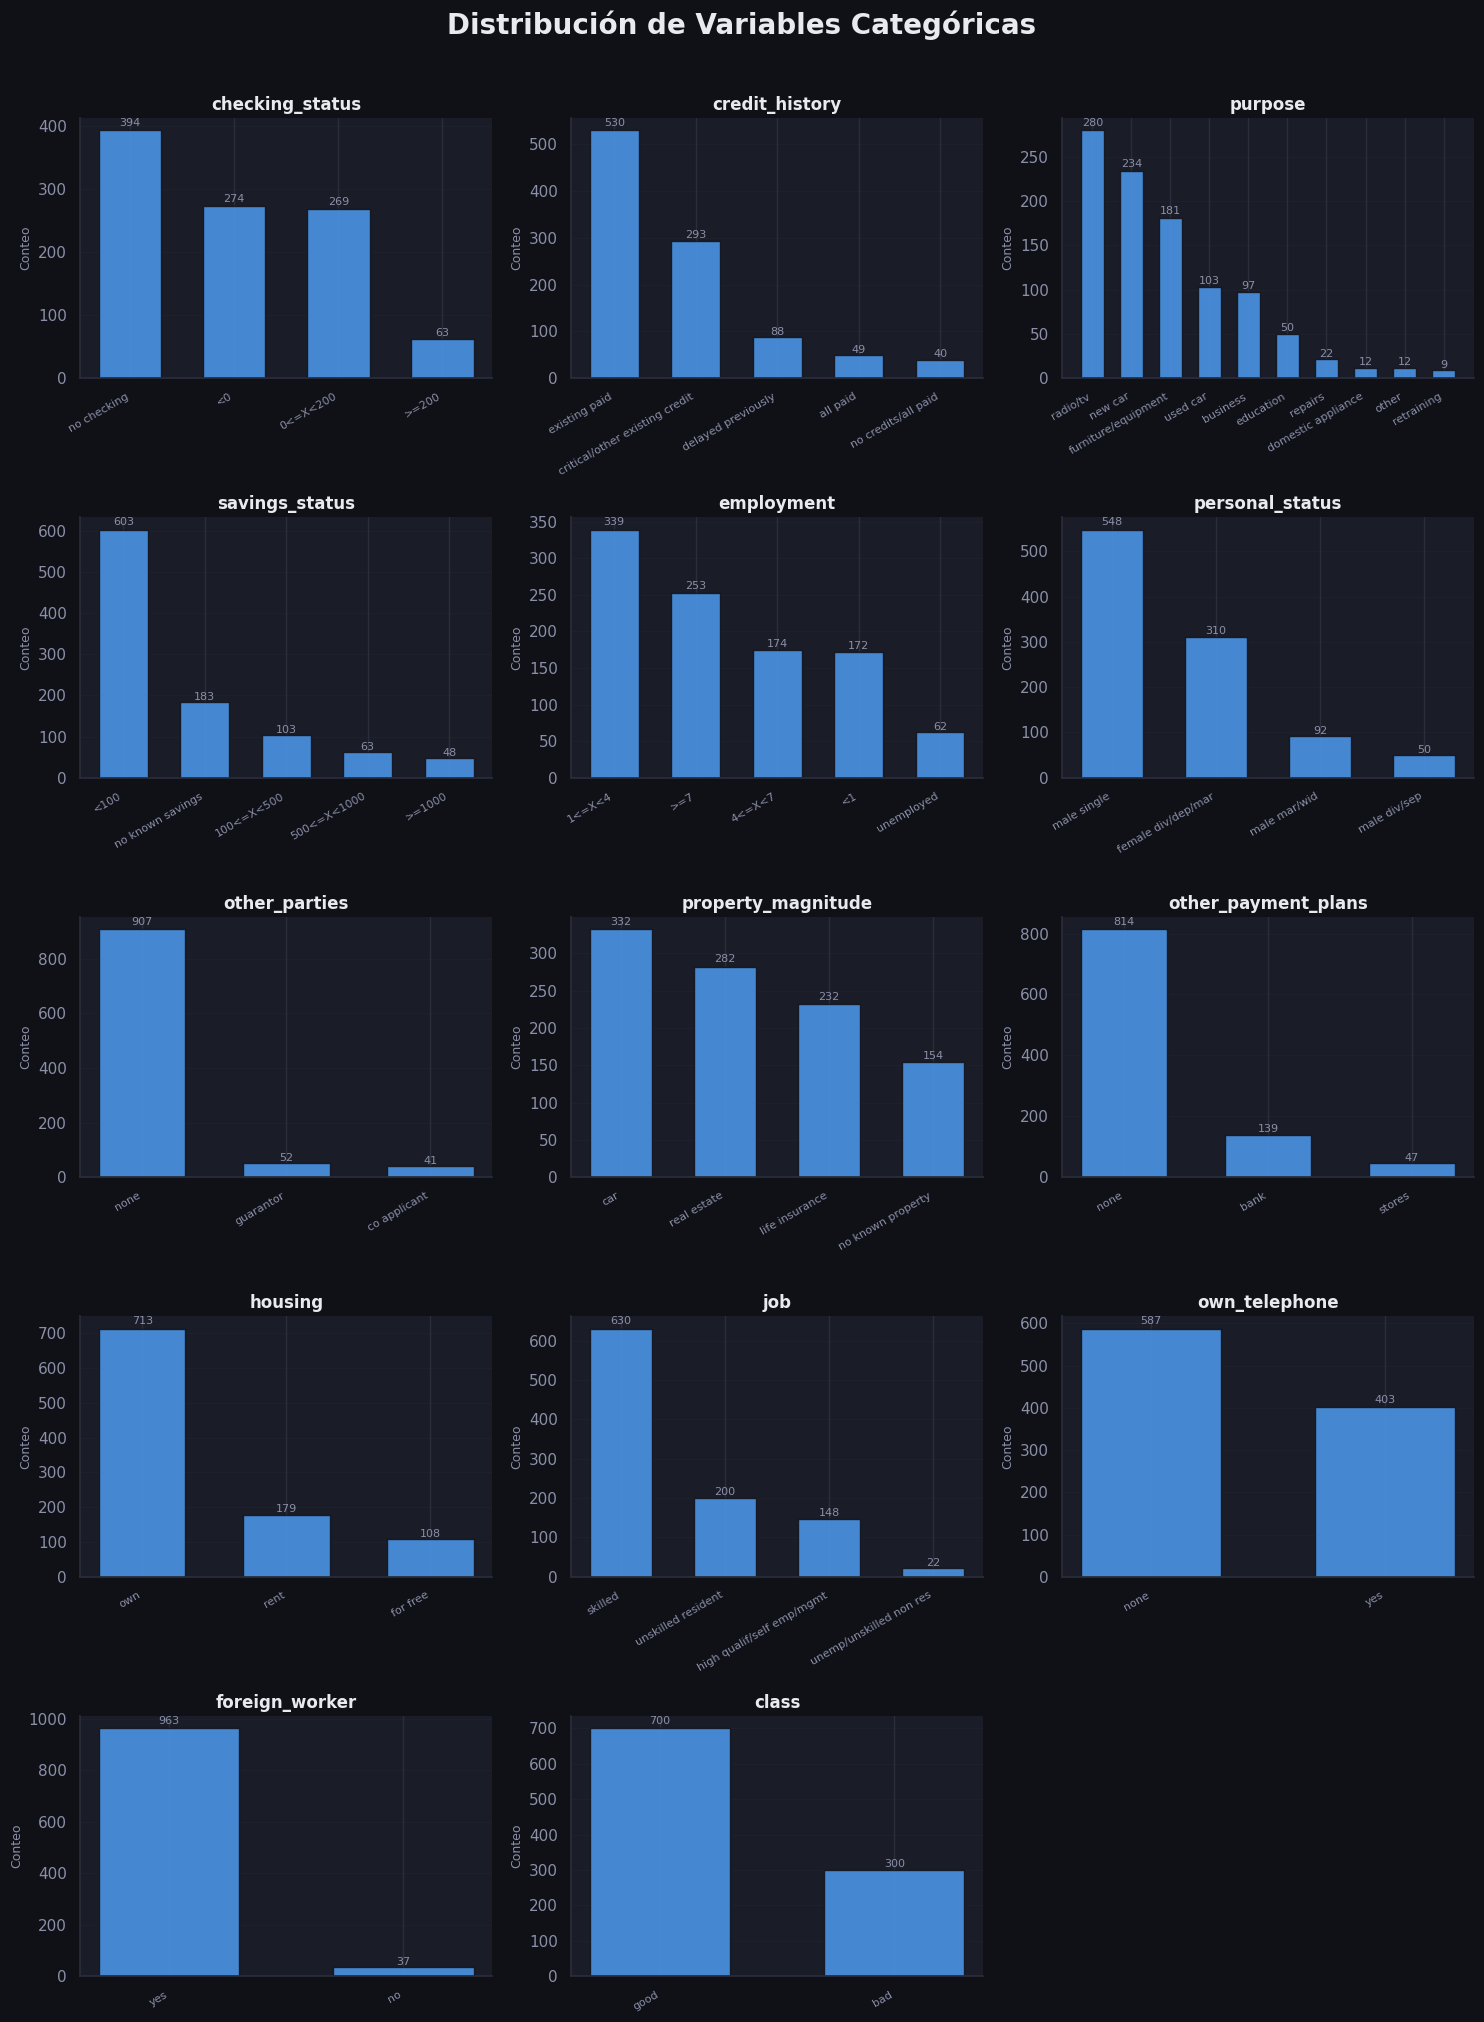

In [26]:
categoricas = creditos.select_dtypes(include=['object', 'category']).columns.tolist()
cols = 3
categoricas = [col for col in categoricas if 'id' not in col.lower()]
rows = int(np.ceil(len(categoricas) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()
fig.suptitle('Distribución de Variables Categóricas', fontsize=20,
            fontweight='bold', color='#e8eaf0', y=1.01)

for i, col in enumerate(categoricas):
    ax = axes[i]
    vc = creditos[col].value_counts()

    bars = ax.bar(range(len(vc)), vc.values, color='#4e9af1',
                edgecolor='#0f1117', alpha=0.85, width=0.6)

    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                str(val), ha='center', va='bottom', fontsize=8, color='#8b8fa8')

    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index.astype(str), fontsize=8, rotation=30, ha='right')
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Conteo', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #1f3a5f; max-width: 700px;">

<ul>
  <li><strong>Historial Crediticio (<code>credit_history</code>):</strong> La gran mayoría de los solicitantes ya tienen historial previo, concentrándose en créditos pagados (<em>existing paid</em>) o en situaciones de créditos críticos/múltiples (<em>critical/other existing credit</em>). Hay muy pocos clientes totalmente "nuevos" (<em>no credits</em>).</li>

  <li><strong>Propósito del Crédito (<code>purpose</code>):</strong> Los préstamos son mayoritariamente. Las categorías dominantes son la compra de tecnología/electrodomésticos (<em>radio/tv</em>) y vehículos (<em>new car</em>, <em>used car</em>). Préstamos para educación o negocios son muy minoritarios.</li>

  
  <li><strong>Estabilidad Laboral (<code>employment</code>):</strong> El banco trata con perfiles estables. La inmensa mayoría de los solicitantes tiene empleo, destacando el grupo con una antigüedad media de entre 1 y 4 años (<em>1<=X<4</em>).</li>
</ul>

<p>Como vemos en la gráfica de <code>purpose</code>, hay muchas categorías con muy pocos registros</p>
</div>

In [10]:

# Extraemos las edades en formato lista para cada categoría
df_good = creditos.loc[creditos["class"] == 'good']['age'].values.tolist()
df_bad = creditos.loc[creditos["class"] == 'bad']['age'].values.tolist()
df_age = creditos['age'].values.tolist()

#  Configurar histogramas:
#  Buen crédito (Good)
trace0 = go.Histogram(
    x=df_good,
    histnorm='probability',
    name="Buen Crédito (Good)",
    marker_color='#2ca02c', # Tono verde
    opacity=0.7
)

# Mal crédito (Bad)
trace1 = go.Histogram(
    x=df_bad,
    histnorm='probability',
    name="Mal Crédito (Bad)",
    marker_color='#d62728', # Tono rojo
    opacity=0.7
)

# Distribución general
trace2 = go.Histogram(
    x=df_age,
    histnorm='probability',
    name="Distribución General",
    marker_color='#1f77b4', # Tono azul
    opacity=0.7
)


fig = make_subplots(
    rows=2, cols=2, 
    specs=[[{}, {}], [{'colspan': 2}, None]],
    subplot_titles=('Distribución Buen Crédito', 'Distribución Mal Crédito', 'Distribución General de Edades')
)

fig.add_trace(trace0, row=1, col=1)
fig.add_trace(trace1, row=1, col=2)
fig.add_trace(trace2, row=2, col=1)

fig.update_layout(
    showlegend=True, 
    title_text='Análisis de Distribución de Edades', 
    bargap=0.05,
    height=600,
    template='plotly_white'
)

fig.show()

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
Como se observa en la gráfica de la variable <strong>edad</strong>, la mayor concentración de solicitantes se sitúa entre los 25 y 30 años.
</p>

<p>
Este patrón se presenta tanto en los créditos concedidos como en los denegados, lo que indica que la distribución de edad es similar en ambas clases.
</p>

<p>
Por tanto, no se puede considerar la edad como un factor discriminante por sí sola, sino como una característica con bajo poder predictivo individual.
</p>

<p>
Este comportamiento refuerza la necesidad de utilizar modelos más complejos, como redes neuronales, capaces de capturar relaciones no lineales y patrones ocultos entre múltiples variables.
</p>

</div>

In [11]:

cuenta_riesgo = creditos.groupby(['checking_status', 'class']).size().reset_index(name='count')

cuenta_riesgo['porcentaje'] = cuenta_riesgo.groupby('checking_status')['count'].transform(lambda x: x / x.sum() * 100)

cuenta_riesgo['class'] = cuenta_riesgo['class'].map({'good': 'Buen Crédito', 'bad': 'Mal Crédito'})

fig2 = px.bar(
    cuenta_riesgo, 
    x='checking_status', 
    y='porcentaje', 
    color='class',
    barmode='group',
    color_discrete_map={'Buen Crédito': "#0400fd", 'Mal Crédito': "#72a5de"},
    labels={'checking_status': 'Estado de la Cuenta Corriente', 'porcentaje': 'Porcentaje (%)', 'class': 'Tipo de Riesgo'},
    title='Riesgo según el Estado de la Cuenta Corriente'
)

fig2.update_layout(template='plotly_white', height=500)
fig2.show()

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
La variable <strong>estado de la cuenta</strong> (<code style="color:#0b5394;">checking_status</code>) presenta un alto poder predictivo.
</p>

<p>
Los clientes sin cuenta corriente o con saldos positivos (≥ 200) muestran una tasa de créditos satisfactorios superior al 80%.
</p>

<p>
En contraste, aquellos con saldo negativo (&lt; 0) representan el grupo de mayor riesgo, alcanzando niveles de morosidad cercanos al 50%.
</p>

</div>

In [12]:

class_counts = creditos['class'].value_counts().reset_index()
class_counts.columns = ['Riesgo', 'Cantidad']

fig_pie = px.pie(
    class_counts, 
    values='Cantidad', 
    names='Riesgo', 
    title='Distribución de la Variable Objetivo (Desbalanceo de Clases)',
    color='Riesgo',
    color_discrete_map={'good': "#67e7ea", 'bad': "#2321bc"},
    hole=0.4 # El hueco en el centro le da un toque moderno
)

fig_pie.update_traces(textposition='inside', textinfo='percent+label', textfont_size=14)
fig_pie.update_layout(template='plotly_white', height=500)
fig_pie.show()

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
El conjunto de datos presenta un desbalanceo de clases significativo: aproximadamente el 70% de los registros corresponden a buenos pagadores (<code style="color:#0b5394;">good</code>) y el 30% a malos pagadores (<code style="color:#0b5394;">bad</code>).
</p>

<p>
Este comportamiento condiciona , ya que requiere el uso de métricas más robustas que el <em>accuracy</em>, la estratificación de los datos durante la división de entrenamiento y prueba (<code style="color:#0b5394;">stratify = y</code>) y la aplicación de técnicas de balanceo como <code style="color:#0b5394;">class_weight='balanced'</code>.
</p>

</div>

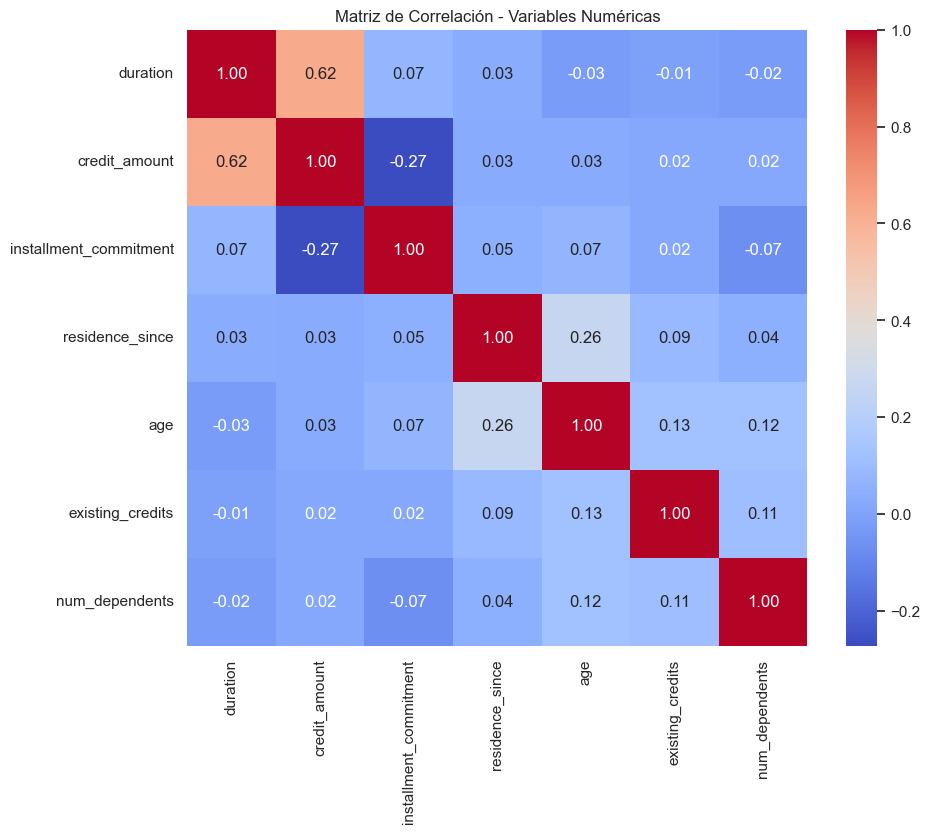

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(creditos[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación - Variables Numéricas')
plt.show()

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
La relación más relevante del conjunto de datos es la correlación positiva entre <code style="color:#0b5394;">duration</code> y <code style="color:#0b5394;">credit_amount</code> (0.62).
</p>

<p>
Este resultado indica que los préstamos de mayor importe suelen asociarse a plazos de devolución más largos, lo cual es coherente desde el punto de vista financiero.
</p>

<p>
Asimismo, se observa una correlación negativa moderada entre <code style="color:#0b5394;">credit_amount</code> e <code style="color:#0b5394;">installment_commitment</code> (-0.27).
</p>

<p>
Esto sugiere que, ante importes elevados, las entidades tienden a ajustar las condiciones del crédito para reducir el impacto de la cuota mensual sobre los ingresos del cliente.
</p>

<p>
Por último, a nivel demográfico, se identifica una correlación positiva leve entre <code style="color:#0b5394;">age</code> y <code style="color:#0b5394;">residence_since</code> (0.26), lo que refleja una mayor estabilidad residencial en clientes de mayor edad.
</p>

</div>

### PREPROCESAMIENTO

In [13]:
creditos_prep = creditos.copy()

creditos_prep = creditos_prep.drop('ID', axis=1)
creditos_prep = creditos_prep[creditos_prep['age'] <= 100]

moda_telefono = creditos_prep['own_telephone'].mode()[0]
creditos_prep['own_telephone'] = creditos_prep['own_telephone'].fillna(moda_telefono)

creditos_prep['class'] = creditos_prep['class'].map({'good': 1, 'bad': 0})



<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
Se aplican las siguientes transformaciones en la fase de preprocesamiento:
</p>

<ul style="margin-top: 8px;">
    <li>
        <strong>Eliminación de <code style="color:#0b5394;">id</code>:</strong> Al tratarse de un identificador único, no aporta valor predictivo al modelo.
    </li>
    <li>
        <strong>Imputación de <code style="color:#0b5394;">own_telephone</code>:</strong> Los valores nulos se reemplazan por la moda. Dado el tamaño reducido del conjunto de datos, se evita la eliminación de registros para no perder información relevante.
    </li>
    <li>
        <strong>Codificación de <code style="color:#0b5394;">class</code>:</strong> La variable objetivo se transforma a formato binario (<code style="color:#0b5394;">good = 1</code>, <code style="color:#0b5394;">bad = 0</code>).
    </li>
</ul>

</div>

In [14]:
# Separación de características (Features) y variable objetivo (Target)

X = creditos_prep.drop('class', axis=1)
y = creditos_prep['class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=seed, 
    stratify=y  # Mantiene la proporción de clases
)

# One-Hot Encoding sin fuga de información (se ajusta en train y se alinea test)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
Las variables categóricas se transforman mediante <strong>One-Hot Encoding</strong>, generando representaciones binarias para cada categoría.
</p>

<p>
Al emplear el parámetro <code style="color:#0b5394;">drop_first = True</code>, se evita la multicolinealidad y se reduce la dimensionalidad del conjunto de datos.
</p>

<p>
Este enfoque contribuye a mejorar la estabilidad del modelo y a mitigar el riesgo de sobreajuste (<em>overfitting</em>).
</p>

</div>

In [15]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- Resumen del Preprocesamiento ---")
print(f"Dimensiones del conjunto de Entrenamiento (X_train_scaled): {X_train_scaled.shape}")
print(f"Dimensiones del conjunto de Prueba (X_test_scaled): {X_test_scaled.shape}")
print(f"Proporción de la clase positiva en Train: {y_train.mean():.2f}")
print(f"Proporción de la clase positiva en Test: {y_test.mean():.2f}")

--- Resumen del Preprocesamiento ---
Dimensiones del conjunto de Entrenamiento (X_train_scaled): (798, 48)
Dimensiones del conjunto de Prueba (X_test_scaled): (200, 48)
Proporción de la clase positiva en Train: 0.70
Proporción de la clase positiva en Test: 0.70


## 3. Creación RRNN, entrenamientos, evaluaciones, predicciones y representación gráfica (4 puntos crédito, 3 puntos cristales)

Esto borra la memoria basura de Keras

In [16]:
tf.keras.backend.clear_session()


In [17]:
n_features = X_train_scaled.shape[1]

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
La arquitectura del modelo se define a partir de los siguientes componentes:
</p>

<ul style="margin-top: 8px;">
    <li>
        <strong>Capas densas:</strong> Adecuadas para datos tabulares, permiten modelar relaciones complejas mediante la conexión completa entre neuronas.
    </li>
    <li>
        <strong>Función de activación (ReLU):</strong> Computacionalmente eficiente y capaz de mitigar el problema del desvanecimiento del gradiente.
    </li>
    <li>
        <strong>Capa de salida y función de pérdida:</strong> Se utiliza una activación <em>sigmoid</em> para obtener probabilidades en el rango [0,1], junto con <em>binary_crossentropy</em>, adecuada para problemas de clasificación binaria.
    </li>
    <li>
        <strong>Optimizador (Adam):</strong> Ajusta dinámicamente la tasa de aprendizaje, favoreciendo una convergencia más rápida y estable.
    </li>
    <li>
        <strong>Regularización (Dropout):</strong> Desactiva aleatoriamente las neuronas durante el entrenamiento para mejorar la generalización y reducir el riesgo de sobreajuste.
    </li>
</ul>

<p>
Se omite el uso de <em>Batch Normalization</em> debido a la posible inestabilidad que puede generar en conjuntos de datos de tamaño reducido.
</p>

</div>

Modelo 1

In [18]:
model_1 = Sequential(name="Red_Simple")
# Capa oculta con 32 neuronas
model_1.add(Dense(32, activation='relu', input_shape=(n_features,)))
# Capa de salida binaria
model_1.add(Dense(1, activation='sigmoid'))

model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_1.summary()

Model: "Red_Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,601 (6.25 KB)

 Trainable params: 1,601 (6.25 KB)

 Non-trainable params: 0 (0.00 B)

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 750px;
">


<p style="text-align: center; font-size: 16px; font-weight: bold; background-color: #f0f4f8; padding: 10px; border-radius: 5px;">
Parámetros = (Neuronas de Entrada × Neuronas de la Capa) + Neuronas de la Capa (Sesgos)
</p>
<ul style="margin-top: 8px;">
    <li>
        <strong>Modelo 1 (Red Simple): Total = 1,601 parámetros</strong>
        <ul>
            <li><em>Capa Oculta (32 neuronas):</em> (48 entradas × 32 neuronas) + 32 sesgos = <strong>1,568</strong></li>
            <li><em>Capa Salida (1 neurona):</em> (32 entradas de la capa anterior × 1 neurona) + 1 sesgo = <strong>33</strong></li>
        </ul>
    </li>
</ul>




</div>

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
<strong>Justificación del modelo</strong>
</p>

<p>
Se utiliza una red neuronal secuencial simple (<em>Sequential</em>) al tratarse de un problema de clasificación binaria estándar.
</p>

<p>
Incluye una capa oculta <code style="color:#0b5394;">Dense(32)</code> con activación <em>ReLU</em>, elegida por su eficiencia computacional.
</p>

<p>
La capa de salida utiliza una única neurona con activación <em>sigmoid</em>, permitiendo obtener probabilidades entre 0 y 1 para clasificar cada cliente.
</p>

<p>
El modelo se compila con el optimizador <em>Adam</em> y la función de pérdida <em>binary_crossentropy</em>, configuraciones estándar y eficaces para clasificación binaria.
</p>


</div>

Modelo 2

In [19]:
model_2 = Sequential(name="Red_Compleja")

# Primera capa oculta (Quitamos BatchNormalization que mete ruido en datasets pequeños)
model_2.add(Dense(64, activation='relu', input_shape=(n_features,)))
model_2.add(Dropout(0.3)) 

# Segunda capa oculta
model_2.add(Dense(32, activation='relu'))
model_2.add(Dropout(0.2))

# Capa de salida binaria
model_2.add(Dense(1, activation='sigmoid'))

# adam -> 0.0005 para que la red no dé pasos tan grandes y no colapse hacia la clase minoritaria.
# optimizador_suave = tf.keras.optimizers.Adam(learning_rate=0.0005)

model_2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_2.summary()

Model: "Red_Compleja"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">
<ul style="margin-top: 8px;">
    <li>
        <strong>Modelo 2 (Red Compleja): Total = 5,249 parámetros</strong>
        <ul>
            <li><em>Capa Oculta 1 (64 neuronas):</em> (48 entradas × 64 neuronas) + 64 sesgos = <strong>3,136</strong></li>
            <li><em>Capa Oculta 2 (32 neuronas):</em> (64 entradas × 32 neuronas) + 32 sesgos = <strong>2,080</strong></li>
            <li><em>Capa Salida (1 neurona):</em> (32 entradas × 1 neurona) + 1 sesgo = <strong>33</strong></li>
        </ul>
    </li>
</ul>
<div>

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
<strong>Justificación del Modelo 2</strong>
</p>

<p>
Red neuronal más profunda para encontra patrones más complejos</p>

<p>
La arquitectura sigue una estructura progresiva (<code style="color:#0b5394;">64 → 32 → 1</code>), permitiendo que la red comprima la información y aprenda representaciones más abstractas.
</p>

<p>
Se utiliza activación <em>ReLU</em> en las capas ocultas por su eficiencia y estabilidad durante el entrenamiento, mientras que la capa final emplea <em>sigmoid</em> para generar probabilidades en un problema de clasificación binaria.
</p>

<p>
El modelo se compila con <em>Adam</em> y <em>binary_crossentropy</em>, manteniendo configuraciones estándar para facilitar la comparación con el modelo simple.
</p>

</div>

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 750px;
">

<hr>
<h3>Selección de Epochs </h3>

<p>
El tamaño reducido del dataset, fijar un número concreto de epochs puede ser peligroso porque la red memorizará los datos (<em>overfitting</em>). 
</p>
<p>
Para solucionarlo establecí un máximo de 150 epochs pero usando <strong>Early Stopping</strong>. Si el error de validación (<code style="color:#0b5394; font-weight:bold;">val_loss</code>) deja de mejorar durante 25 épocas consecutivas, el entrenamiento se corta automáticamente y el modelo recupera los pesos de su mejor momento.
</p>

</div>

In [20]:

early_stop1 = EarlyStopping(
    monitor='val_loss', 
    patience=25, 
    restore_best_weights=True
) # para el modelo 1 

early_stop2 = EarlyStopping(
    monitor='val_loss', 
    patience=25, 
    restore_best_weights=True
) # para el modelo 2

class_weight_values = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weight_values))
print(f"Pesos de clase usados en entrenamiento: {class_weight_dict}")

history_1 = model_1.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop1],
    class_weight=class_weight_dict,
    verbose=0
)
print(f"Modelo 1 detenido en la época {len(history_1.epoch)}")

history_2 = model_2.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop2],
    class_weight=class_weight_dict,
    verbose=0
)
print(f"Modelo 2 detenido en la época {len(history_2.epoch)}")

loss_1, acc_1 = model_1.evaluate(X_test_scaled, y_test, verbose=0)
loss_2, acc_2 = model_2.evaluate(X_test_scaled, y_test, verbose=0)

y_prob_1 = model_1.predict(X_test_scaled, verbose=0).ravel()
y_prob_2 = model_2.predict(X_test_scaled, verbose=0).ravel()
y_pred_class_1 = (y_prob_1 >= 0.5).astype(int)
y_pred_class_2 = (y_prob_2 >= 0.5).astype(int)

print("\n--- Resultados de Evaluación en Test ---")
for name, y_prob, y_pred, loss, acc in [
    ("Modelo 1 (Simple)", y_prob_1, y_pred_class_1, loss_1, acc_1),
    ("Modelo 2 (Complejo)", y_prob_2, y_pred_class_2, loss_2, acc_2)
]:
    print(
        f"{name} -> Loss: {loss:.4f} | Accuracy: {acc*100:.2f}% | "
        f"Balanced Acc: {balanced_accuracy_score(y_test, y_pred):.4f} | "
        f"F1 clase 0: {f1_score(y_test, y_pred, pos_label=0):.4f} | "
        f"Recall clase 0: {recall_score(y_test, y_pred, pos_label=0):.4f} | "
        f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}"
    )
    print(classification_report(y_test, y_pred, digits=4))

Pesos de clase usados en entrenamiento: {np.int64(0): np.float64(1.6625), np.int64(1): np.float64(0.7150537634408602)}
Modelo 1 detenido en la época 49
Modelo 2 detenido en la época 37

--- Resultados de Evaluación en Test ---
Modelo 1 (Simple) -> Loss: 0.5857 | Accuracy: 67.00% | Balanced Acc: 0.6405 | F1 clase 0: 0.5075 | Recall clase 0: 0.5667 | ROC-AUC: 0.7630
              precision    recall  f1-score   support

           0     0.4595    0.5667    0.5075        60
           1     0.7937    0.7143    0.7519       140

    accuracy                         0.6700       200
   macro avg     0.6266    0.6405    0.6297       200
weighted avg     0.6934    0.6700    0.6786       200

Modelo 2 (Complejo) -> Loss: 0.5517 | Accuracy: 71.00% | Balanced Acc: 0.6976 | F1 clase 0: 0.5797 | Recall clase 0: 0.6667 | ROC-AUC: 0.7771
              precision    recall  f1-score   support

           0     0.5128    0.6667    0.5797        60
           1     0.8361    0.7286    0.7786       140



<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
Debido al desbalanceo del dataset analizado anteriormente, el <em>accuracy</em> por sí solo no era suficiente para evaluar el modelo.
</p>

<p>
Por lo tanto utilice métricas como <em>Recall</em>, <em>F1-Score</em>, <em>Balanced Accuracy</em>  <em>ROC-AUC</em>, además de aplicar <code style="color:#0b5394;">class_weights</code> para dar mayor importancia a la clase minoritaria.
</p>

<p>
El Modelo 2 obtuvo los mejores resultados, especialmente en la detección de malos pagadores, logrando una mejor capacidad de generalización y un rendimiento más equilibrado.
</p>

</div>

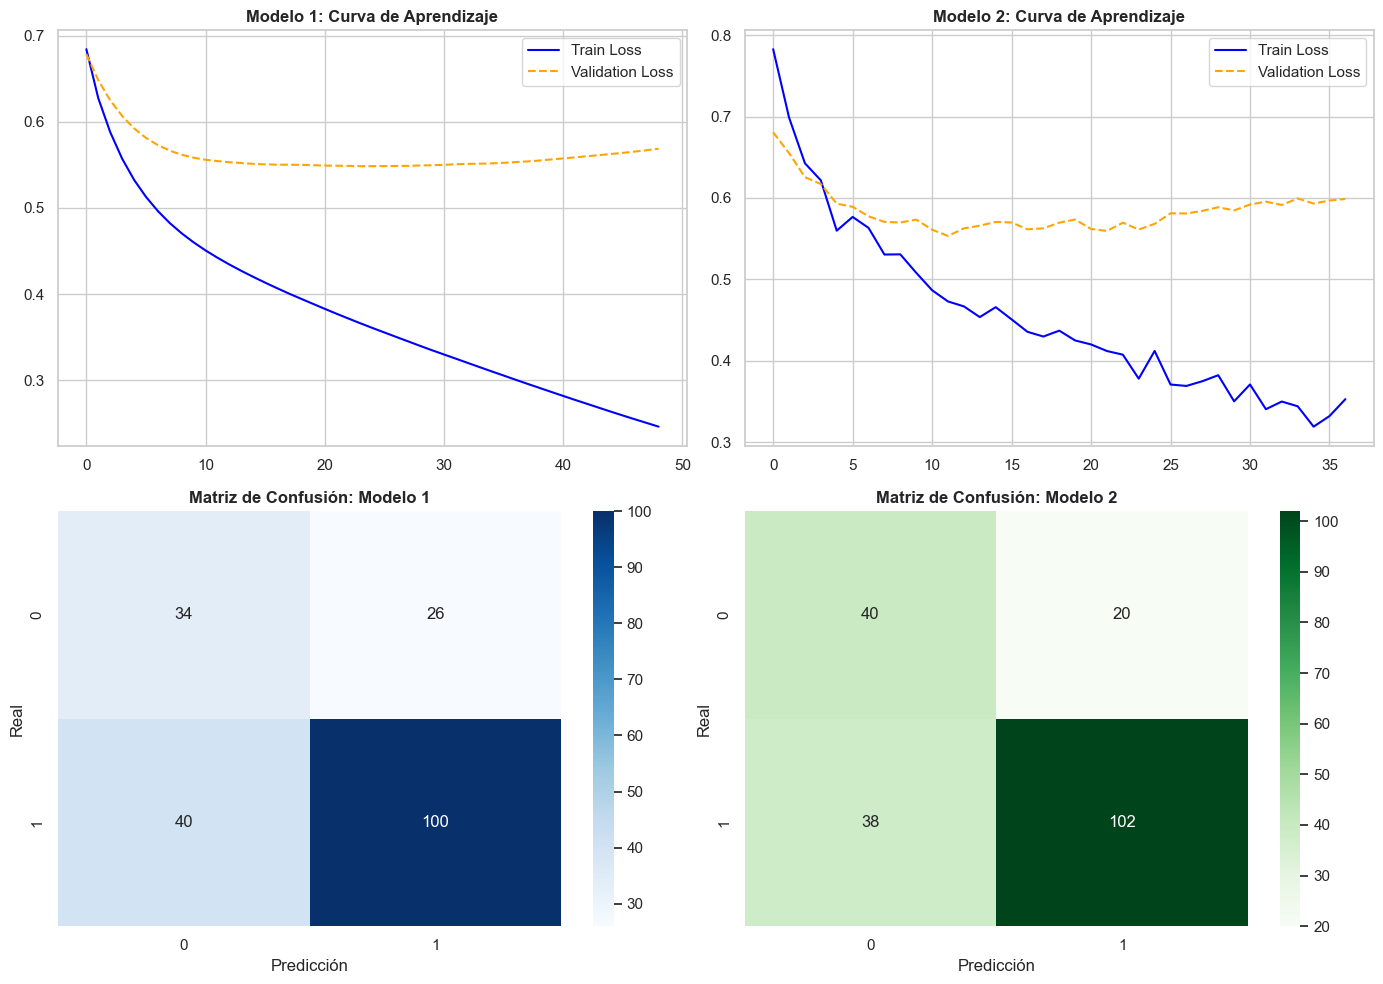

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Curva Loss Modelo 1
axes[0, 0].plot(history_1.history['loss'], label='Train Loss', color='blue')
axes[0, 0].plot(history_1.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
axes[0, 0].set_title('Modelo 1: Curva de Aprendizaje', fontweight='bold')
axes[0, 0].legend()

# Curva Loss Modelo 2
axes[0, 1].plot(history_2.history['loss'], label='Train Loss', color='blue')
axes[0, 1].plot(history_2.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
axes[0, 1].set_title('Modelo 2: Curva de Aprendizaje', fontweight='bold')
axes[0, 1].legend()


# Matriz Modelo 1
sns.heatmap(confusion_matrix(y_test, y_pred_class_1), annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Matriz de Confusión: Modelo 1', fontweight='bold')
axes[1, 0].set_ylabel('Real'), axes[1, 0].set_xlabel('Predicción')

# Matriz Modelo 2
sns.heatmap(confusion_matrix(y_test, y_pred_class_2), annot=True, fmt='d', cmap='Greens', ax=axes[1, 1])
axes[1, 1].set_title('Matriz de Confusión: Modelo 2', fontweight='bold')
axes[1, 1].set_ylabel('Real'), axes[1, 1].set_xlabel('Predicción')

plt.tight_layout()
plt.show()

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
Las gráficas de entrenamiento y las matrices de confusión muestran que el Modelo 2 presenta un aprendizaje más estable y equilibrado.
</p>

<p>
Gracias al uso de regularización, limpieza de datos y <code style="color:#0b5394;">class_weights</code>, el modelo logra reducir mejor el error y detectar más clientes de riesgo sin perjudicar significativamente la clasificación de buenos pagadores.
</p>

<p>
En comparación con el Modelo 1, el Modelo 2 reduce los falsos positivos y mejora la identificación de malos pagadores, lo que representa una ventaja importante desde el punto de vista financiero.
</p>

</div>

## 4. Selección de otro modelo de aprendizaje supervisado (2 puntos)

--- Cross-Validation ---
LR -> Media de Balanced Accuracy: 0.7121 | Desviación Estándar: 0.0539
KNN -> Media de Balanced Accuracy: 0.6249 | Desviación Estándar: 0.0510
CART -> Media de Balanced Accuracy: 0.6062 | Desviación Estándar: 0.0609
RF -> Media de Balanced Accuracy: 0.6485 | Desviación Estándar: 0.0413
SVM -> Media de Balanced Accuracy: 0.7133 | Desviación Estándar: 0.0462


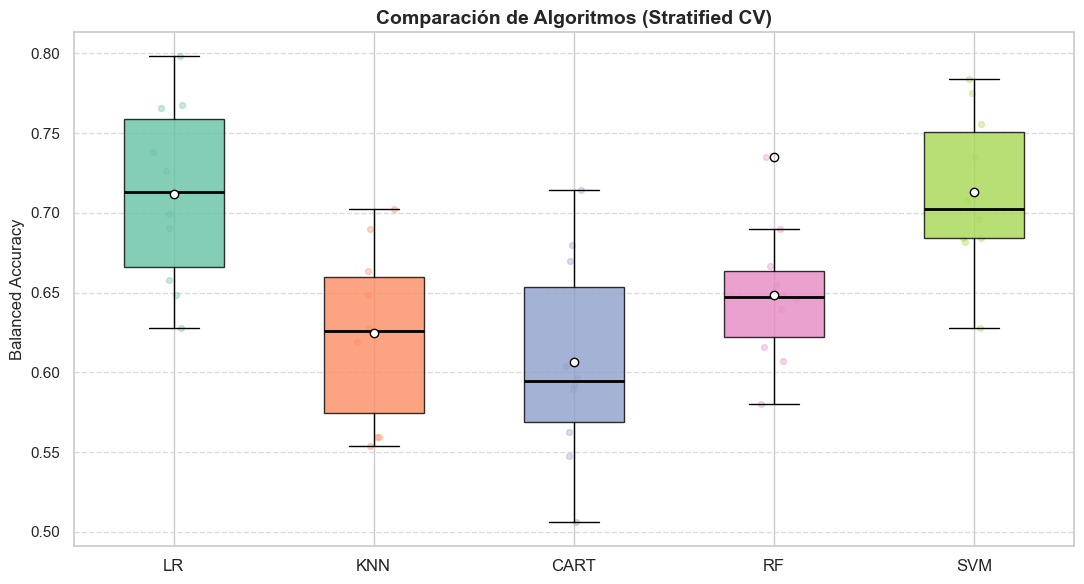

In [22]:
models = []
models.append(('LR', LogisticRegression(max_iter=1000, class_weight='balanced'))) 
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier(random_state=seed)))
models.append(('RF', RandomForestClassifier(random_state=seed, class_weight='balanced')))
models.append(('SVM', SVC(gamma='auto', class_weight='balanced')))

results = []
names = []
scoring = 'balanced_accuracy' 

print("--- Cross-Validation ---")
for name, model in models:
    # shuffle=True es necesario en las nuevas versiones si usamos random_state
    kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    print(f"{name} -> Media de Balanced Accuracy: {cv_results.mean():.4f} | Desviación Estándar: {cv_results.std():.4f}")
        
plt.figure(figsize=(11, 6))

palette = sns.color_palette('Set2', n_colors=len(names))
box = plt.boxplot(
    results,
    patch_artist=True,
    labels=names,
    showmeans=True,
    meanprops=dict(marker='o', markerfacecolor='white', markeredgecolor='black', markersize=6),
    medianprops=dict(color='black', linewidth=2)
)

for patch, color in zip(box['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

for i, scores in enumerate(results, start=1):
    x_jitter = np.random.normal(i, 0.04, size=len(scores))
    plt.scatter(x_jitter, scores, color=palette[i-1], alpha=0.35, s=18)

plt.xticks(fontsize=12)
plt.title('Comparación de Algoritmos (Stratified CV)', fontsize=14, fontweight='bold')
plt.ylabel('Balanced Accuracy', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">
<p>
Al aplicar validación cruzada con <code style="color:#0b5394;">StratifiedKFold</code> y <em>balanced accuracy</em>, observamos que la <strong>Regresión Logística (LR)</strong> presenta el mejor rendimiento promedio respecto a los demás.
</p>
<p>
Este algoritmo es una excelente opción para realizar esta clasificación binaria.
</p>

</div>

In [28]:

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=seed)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
bal_acc_lr = balanced_accuracy_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print(f"--- Resultados Regresión Logística en Test ---")
print(f"Accuracy Global: {acc_lr*100:.2f}%")
print(f"Balanced Accuracy: {bal_acc_lr:.4f}")
print(f"ROC-AUC: {roc_auc_lr:.4f}\n")
print(classification_report(y_test, y_pred_lr))

--- Resultados Regresión Logística en Test ---
Accuracy Global: 68.50%
Balanced Accuracy: 0.6798
ROC-AUC: 0.7806

              precision    recall  f1-score   support

           0       0.48      0.67      0.56        60
           1       0.83      0.69      0.75       140

    accuracy                           0.69       200
   macro avg       0.66      0.68      0.66       200
weighted avg       0.72      0.69      0.70       200



<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
La Regresión Logística muestra un rendimiento equilibrado, mejorando la detección de la clase minoritaria gracias al uso de <code style="color:#0b5394;">class_weight='balanced'</code>.
</p>

<p>
Su principal ventaja es la interpretabilidad, ya que permite identificar qué variables aumentan o reducen el riesgo crediticio.
</p>

<p>
Además, el valor de <em>ROC-AUC</em> indica una buena capacidad para diferenciar entre buenos y malos pagadores.
</p>

</div>

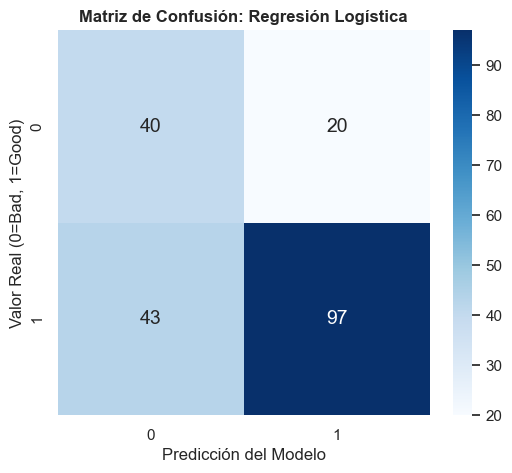

In [32]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', annot_kws={"size": 14})
plt.title('Matriz de Confusión: Regresión Logística', fontweight='bold')
plt.ylabel('Valor Real (0=Bad, 1=Good)')
plt.xlabel('Predicción del Modelo')
plt.show()

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">


<p>
La Regresión Logística logra detectar correctamente muchos clientes con riesgo de impago, mostrando un comportamiento bastante equilibrado.
</p>

<p>
Aunque en algunos casos rechaza clientes que sí habrían pagado, el modelo mantiene una buena capacidad para proteger al banco frente a posibles pérdidas.
</p>

<p>
Además, una de sus principales ventajas es que permite entender fácilmente qué factores influyen en cada decisión.
</p>

</div>

## 5. Análisis comparativo y Conclusiones (2 puntos)

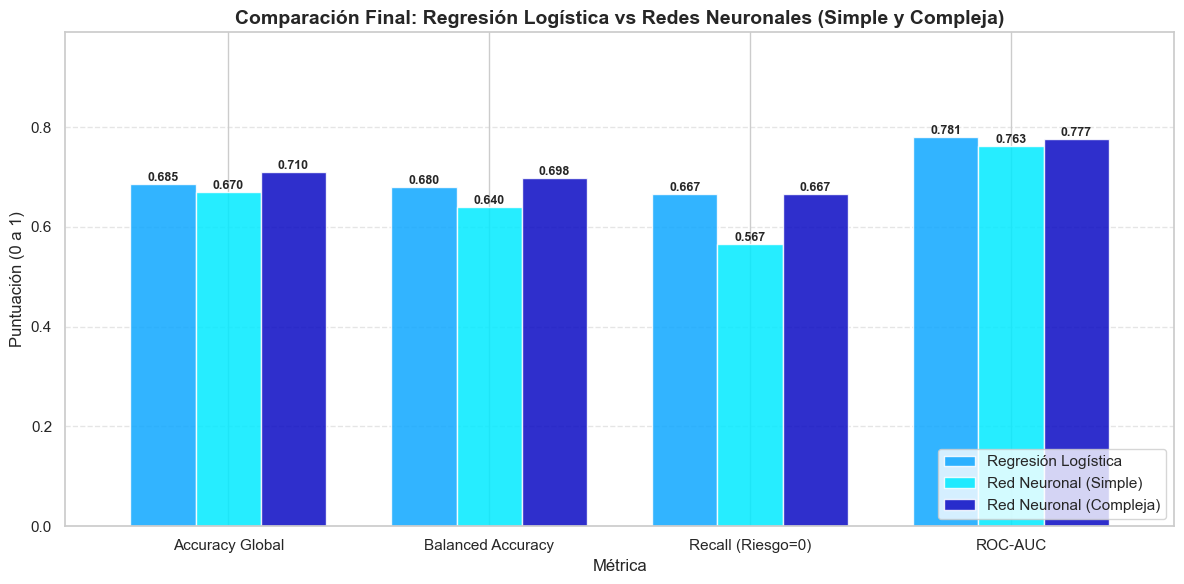

In [36]:
#  Modelo 1 (Simple)
bal_acc_m1 = balanced_accuracy_score(y_test, y_pred_class_1)
recall_m1  = recall_score(y_test, y_pred_class_1, pos_label=0)
roc_m1     = roc_auc_score(y_test, y_prob_1)

# Modelo 2 (Complejo)
bal_acc_m2 = balanced_accuracy_score(y_test, y_pred_class_2)
recall_m2  = recall_score(y_test, y_pred_class_2, pos_label=0)
roc_m2     = roc_auc_score(y_test, y_prob_2)

datos_comparacion = {
    'Métrica': ['Accuracy Global', 'Balanced Accuracy', 'Recall (Riesgo=0)', 'ROC-AUC'],
    'Regresión Logística': [acc_lr, bal_acc_lr, recall_score(y_test, y_pred_lr, pos_label=0), roc_auc_lr],
    'Red Neuronal (Simple)': [acc_1, bal_acc_m1, recall_m1, roc_m1],
    'Red Neuronal (Compleja)': [acc_2, bal_acc_m2, recall_m2, roc_m2]
}

df_comp = pd.DataFrame(datos_comparacion).set_index('Métrica')

ax = df_comp.plot(kind='bar', figsize=(12, 6), color=["#0ea7ff", "#00eaff", "#0a0ac3"], width=0.75, alpha=0.85)

plt.title('Comparación Final: Regresión Logística vs Redes Neuronales (Simple y Compleja)', fontsize=14, fontweight='bold')
plt.ylabel('Puntuación (0 a 1)', fontsize=12)
plt.ylim(0, 0.99) # Damos espacio por arriba para que quepan los números
plt.xticks(rotation=0, fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

<div style="font-family: 'Segoe UI', Arial, sans-serif; line-height: 1.6; color: #1f3a5f; max-width: 700px;">

<h3>¿Con cuál te quedas y qué motivos crees que han condicionado tus resultados?</h3>
<p>
Elijo la <strong>Regresión Logística</strong>. Aunque la Red Neuronal Compleja obtiene 
un accuracy global y balanced accuracy ligeramente superiores (0.710 vs 0.685 y 0.698 vs 0.680), 
las diferencias son mínimas. En cambio, la Regresión Logística empata en la métrica más crítica 
para este problema —el <strong>Recall sobre malos pagadores (0.667)</strong>— y supera a ambas 
redes en <strong>ROC-AUC (0.781)</strong>, que mide la capacidad discriminativa global del modelo.
</p>
<p>
<em>No detectar a un mal pagador es más costoso que rechazar a uno bueno</em>, 
por lo que el recall y el ROC-AUC son las métricas determinantes.
</p>
<p>Los factores que más han condicionado los resultados son:</p>
<ul>
  <li><strong>Desbalanceo de clases (70/30):</strong> Obligó a usar <code>class_weight='balanced'</code> 
  y métricas como Balanced Accuracy y ROC-AUC en lugar del accuracy tradicional.</li>
  <li><strong>Tamaño reducido del dataset (~1000 registros):</strong> Limita el potencial de la red 
  neuronal, que necesita más datos para superar claramente a modelos lineales.</li>
  <li><strong>Alta dimensionalidad tras el One-Hot Encoding:</strong> Favoreció la estabilidad de la Regresión Logística.</li>
</ul>

<h3>¿Estás satisfecha y/o tienes alguna propuesta de mejora? Justifica tus respuestas</h3>
<p>
Los resultados son razonables dado el tamaño del dataset, pero el recall de la clase minoritaria 
(0.667) indica que aún se nos escapa 1 de cada 3 malos pagadores. Las propuestas de mejora son:
</p>
<ul>
  <li><strong>SMOTE:</strong> Generar instancias sintéticas de malos pagadores en el preprocesamiento para mejorar 
  el recall sin depender exclusivamente de los pesos de clase.</li>
  <li><strong>Ajuste del umbral de decisión:</strong> Bajar el umbral por defecto (0.5) en la Regresión Logística para 
  priorizar la detección de riesgo, asumiendo un ligero coste en Falsos Positivos y accuracy global.</li>
  <li><strong>Optimización del hiperparámetro C:</strong> Aplicar <code>GridSearchCV</code> 
  sobre el parámetro de regularización <code>C</code> para encontrar el equilibrio matemático óptimo 
  entre sesgo y varianza.</li>
</ul>

</div>